# Bidirectional linear regression before Information Imbalance

This notebook develops an intuitive and quantitative view of four held-out spaces:


$X,\qquad Y,\qquad \hat Y=f_{\mathrm{lin}}(X),\qquad
\hat X=g_{\mathrm{lin}}(Y),$

and their residuals


$R_Y=Y-\hat Y,\qquad R_X=X-\hat X.$

The central question is whether asymmetric neighborhood information remains after each representation is projected through the opposite representation. Every regression is fitted on a training split. Predictions, residuals, plots, RDM comparisons, and Information Imbalance (II) are computed only on the same held-out observations.

Throughout, observations occupy rows:

$X\in\mathbb{R}^{N\times D},\qquad Y\in\mathbb{R}^{N\times d}.$

## 1. Imports and helper functions

Predictors are standardized with training-set means and standard deviations only. Targets remain in their original coordinates, so predictions and residuals are directly comparable to the held-out targets. All functions below use explicit array-shape checks and deterministic seeds.

The project names its static regression wrapper `linear_encoding`; both regression directions below use that class's `fit`, `predict`, `score`, and coefficient getters. All directional II values and neighborhood ranks are computed with the project's `InformationImbalance` class. The notebook helpers only adapt between the notebook orientation $N\times D$ and the project convention `(features, samples)`.

In [1]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import Markdown, display
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Locate config.yaml whether Jupyter starts in the repository or scripts folder.
cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / "config.yaml").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate config.yaml from the current directory.")
# end if PROJECT_ROOT is None

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    project_config = yaml.safe_load(f)
paths = project_config[ENV]["paths"]
sys.path.append(paths["useful_stuff_path"])

from useful_stuff.general_utils.II import InformationImbalance
from useful_stuff.general_utils.regression import linear_encoding

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})


@dataclass
class Cfg:
    test_size: float = 0.35
    regression_alpha: float = 1e-8
    k: int = 5
    seed: int = 20260722
# EOC


cfg = Cfg()
cfg

Cfg(test_size=0.35, regression_alpha=1e-08, k=5, seed=20260722)

In [2]:
def display_table(rows, precision=4):
    """Render a list of dictionaries as a compact Markdown table."""
    if not rows:
        display(Markdown("_No rows to display._"))
        return
    # end if not rows
    headers = list(rows[0])

    def format_value(value):
        if isinstance(value, (float, np.floating)):
            return f"{value:.{precision}f}" if np.isfinite(value) else "NaN"
        # end if isinstance(value, (float, np.floating))
        return str(value).replace("|", "\\|")
    # EOF

    escaped_headers = [str(header).replace("|", "\\|") for header in headers]
    lines = [
        "| " + " | ".join(escaped_headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
    ]
    for row in rows:
        lines.append("| " + " | ".join(format_value(row.get(header, "")) for header in headers) + " |")
    # end for row
    display(Markdown("\n".join(lines)))
# EOF

In [3]:
"""
as_2d
Convert a one-dimensional observation vector to an (N, 1) matrix.

INPUT:
    - data: np.ndarray -> observations in rows

OUTPUT:
    - data: np.ndarray -> two-dimensional floating-point matrix
"""
def as_2d(data):
    data = np.asarray(data, dtype=float)
    if data.ndim == 1:
        data = data[:, None]
    # end if data.ndim == 1
    if data.ndim != 2:
        raise ValueError(f"Expected an (observations, features) matrix, got {data.shape}.")
    # end if data.ndim != 2
    return data
# EOF


"""
make_linear_encoding
Initialize the project linear_encoding class for one fixed regularization value.
An alpha of zero selects ordinary linear regression; a positive alpha selects
RidgeCV with a one-value alpha grid.

INPUT:
    - alpha: float -> fixed ridge regularization, or zero for ordinary regression

OUTPUT:
    - encoding: linear_encoding -> initialized project regression object
"""
def make_linear_encoding(alpha):
    if alpha < 0:
        raise ValueError("alpha must be non-negative.")
    # end if alpha < 0
    regression_type = "lr" if alpha == 0 else "ridge"
    alphas = np.array([alpha if alpha > 0 else 1.0], dtype=float)
    return linear_encoding(
        regression_type=regression_type,
        cv_type="same",
        alphas=alphas,
        score_type="r2",
        shuffle=False,
    )
# EOF


"""
fit_bidirectional_linear
Fit X -> Y and Y -> X with the project linear_encoding class on one training
split, then evaluate both directions on the same held-out observations. Each
predictor scaler is fitted on training data only.

INPUT:
    - X: np.ndarray -> shape (N, D)
    - Y: np.ndarray -> shape (N, d)
    - test_size: float -> fraction of held-out observations
    - seed: int -> split seed
    - alpha: float -> ridge regularization; zero selects ordinary regression

OUTPUT:
    - result: dict -> split arrays, predictions, residuals, encoders, and R² values
"""
def fit_bidirectional_linear(X, Y, test_size=0.35, seed=0, alpha=1e-8):
    X = as_2d(X)
    Y = as_2d(Y)
    if X.shape[0] != Y.shape[0]:
        raise ValueError("X and Y must contain the same observations.")
    # end if X.shape[0] != Y.shape[0]

    observation_idx = np.arange(X.shape[0])
    train_idx, test_idx = train_test_split(
        observation_idx, test_size=test_size, random_state=seed, shuffle=True
    )

    # Fit each predictor standardizer without using held-out observations.
    X_scaler = StandardScaler().fit(X[train_idx])
    Y_scaler = StandardScaler().fit(Y[train_idx])
    X_train_z = X_scaler.transform(X[train_idx])
    X_test_z = X_scaler.transform(X[test_idx])
    Y_train_z = Y_scaler.transform(Y[train_idx])
    Y_test_z = Y_scaler.transform(Y[test_idx])

    # Use the project regression class in both directions.
    X_to_Y = make_linear_encoding(alpha)
    Y_to_X = make_linear_encoding(alpha)
    X_to_Y.fit(X_train_z, Y[train_idx], transpose=False)
    Y_to_X.fit(Y_train_z, X[train_idx], transpose=False)

    Y_hat = as_2d(
        X_to_Y.predict(X_test_z, transpose=False, transpose_output=False)
    )
    X_hat = as_2d(
        Y_to_X.predict(Y_test_z, transpose=False, transpose_output=False)
    )
    X_test = X[test_idx]
    Y_test = Y[test_idx]
    R_X = X_test - X_hat
    R_Y = Y_test - Y_hat

    # R² is also computed through the project class on held-out predictions.
    r2_X_to_Y = X_to_Y.score(
        X_test_z,
        Y_test,
        y_hat=Y_hat,
        transpose=False,
        transpose_prediction=False,
    )
    r2_Y_to_X = Y_to_X.score(
        Y_test_z,
        X_test,
        y_hat=X_hat,
        transpose=False,
        transpose_prediction=False,
    )

    return {
        "train_idx": train_idx,
        "test_idx": test_idx,
        "X": X_test,
        "Y": Y_test,
        "X_hat": X_hat,
        "Y_hat": Y_hat,
        "R_X": R_X,
        "R_Y": R_Y,
        "X_to_Y": X_to_Y,
        "Y_to_X": Y_to_X,
        "X_scaler": X_scaler,
        "Y_scaler": Y_scaler,
        "r2_X_to_Y": r2_X_to_Y,
        "r2_Y_to_X": r2_Y_to_X,
        "alpha": alpha,
        "seed": seed,
    }
# EOF

In [4]:
"""
make_ii_object
Initialize the project InformationImbalance class for Euclidean RDMs.

INPUT:
    - k: int -> number of conditioning neighbors

OUTPUT:
    - ii_obj: InformationImbalance -> initialized project II object
"""
def make_ii_object(k=1):
    return InformationImbalance(
        signal_RDM_metric="euclidean",
        model_RDM_metric="euclidean",
        k=k,
    )
# EOF


"""
pairwise_euclidean
Compute an observation-by-observation Euclidean distance matrix through the RDM
machinery inherited by the project InformationImbalance class.

INPUT:
    - data: np.ndarray -> shape (N, features)

OUTPUT:
    - distances: np.ndarray -> shape (N, N)
"""
def pairwise_euclidean(data):
    data = as_2d(data)
    ii_obj = make_ii_object(k=1)
    condensed_RDM = ii_obj.compute_RDM(data.T, "signal")
    return squareform(condensed_RDM)
# EOF


"""
nearest_neighbor_ranks
Return neighbor identities and zero-based distance ranks using the project's
InformationImbalance.compute_distance_ranks method. The class excludes self by
setting the RDM diagonal to infinity.

INPUT:
    - data: np.ndarray -> shape (N, features)

OUTPUT:
    - distances: np.ndarray -> Euclidean distances with an infinite diagonal
    - order: np.ndarray -> neighbor indices from nearest to farthest per anchor
    - ranks: np.ndarray -> ranks[anchor, point], with nearest non-self rank zero
"""
def nearest_neighbor_ranks(data):
    data = as_2d(data)
    ii_obj = make_ii_object(k=1)
    ii_obj.compute_RDM(data.T, "signal")
    point_by_anchor_ranks, _ = ii_obj.compute_distance_ranks("signal")

    distances = squareform(ii_obj.get_RDM("signal"))
    np.fill_diagonal(distances, np.inf)
    ranks = point_by_anchor_ranks.T.astype(int)
    order = np.argsort(ranks, axis=1)
    return distances, order, ranks
# EOF


"""
directional_ii
Compute project Information Imbalance from source to target.

INPUT:
    - source: np.ndarray -> conditioning representation, shape (N, features)
    - target: np.ndarray -> conditioned representation, shape (N, features)
    - k: int -> number of source neighbors used per anchor

OUTPUT:
    - delta: float -> directional Information Imbalance
"""
def directional_ii(source, target, k=1):
    source = as_2d(source)
    target = as_2d(target)
    if source.shape[0] != target.shape[0]:
        raise ValueError("Source and target must contain the same observations.")
    # end if source.shape[0] != target.shape[0]
    if not 1 <= k < source.shape[0]:
        raise ValueError("k must satisfy 1 <= k < N.")
    # end if not 1 <= k < source.shape[0]

    ii_obj = make_ii_object(k)
    ii_obj.compute_both_RDMs(source.T, target.T)
    ii_obj.compute_both_distance_ranks()
    return float(ii_obj.compute_II("A2B"))
# EOF


def bidirectional_ii(A, B, k=1):
    """Return project Delta(A -> B) and Delta(B -> A)."""
    A = as_2d(A)
    B = as_2d(B)
    ii_obj = make_ii_object(k)
    ii_obj.compute_both_RDMs(A.T, B.T)
    ii_obj.compute_both_distance_ranks()
    delta_A_B, delta_B_A = ii_obj.compute_both_II()
    return float(delta_A_B), float(delta_B_A)
# EOF


def rdm_spearman(A, B):
    """Spearman correlation between flattened upper-triangular Euclidean RDMs."""
    if np.var(A) < 1e-14 or np.var(B) < 1e-14:
        return np.nan
    # end if either space is geometrically degenerate
    return float(spearmanr(pdist(as_2d(A)), pdist(as_2d(B))).statistic)
# EOF

### II normalization and tie convention

Every II value below is returned by the project `InformationImbalance` class. The class uses

$$
\Delta(A\rightarrow B)=\frac{2}{N^2k}
\sum_{i=1}^{N}\sum_{j\in\mathcal N_k^A(i)} r_B(i,j).
$$

The closest non-self point has rank 0. `InformationImbalance.compute_distance_ranks` excludes self-distances by setting the RDM diagonal to infinity. With identical, tie-free geometry, the minimum is therefore $(k-1)/N$, which is exactly zero only for $k=1$.

The class uses NumPy's default `argsort`, so exact distance ties are resolved according to NumPy's ordering rather than an explicit stable tie rule. The next cell independently reproduces the project normalization and checks the class-backed wrapper above.

In [5]:
def project_reference_directional_ii(source, target, k=1):
    """Independent column-oriented reproduction of the project II convention."""
    source_distances = pairwise_euclidean(source)
    target_distances = pairwise_euclidean(target)
    np.fill_diagonal(source_distances, np.inf)
    np.fill_diagonal(target_distances, np.inf)

    source_order = np.argsort(source_distances, axis=0)
    target_order = np.argsort(target_distances, axis=0)
    target_ranks = np.argsort(target_order, axis=0)
    target_ranks = target_ranks + 2 * np.eye(target_ranks.shape[0], dtype=int)
    source_neighbors = source_order[:k, :]
    conditioned_ranks = np.take_along_axis(target_ranks, source_neighbors, axis=0)
    n_observations = source_distances.shape[0]
    return float(2 * conditioned_ranks.sum() / (n_observations**2 * k))
# EOF


verification_rng = np.random.default_rng(9102)
verification_A = verification_rng.normal(size=(80, 3))
verification_B = verification_rng.normal(size=(80, 5))
for verification_k in (1, 3, 8):
    class_value = directional_ii(verification_A, verification_B, verification_k)
    reference_value = project_reference_directional_ii(
        verification_A, verification_B, verification_k
    )
    np.testing.assert_allclose(class_value, reference_value, atol=1e-15)
# end for verification_k

print("InformationImbalance output verified against the explicit reference formula.")

InformationImbalance output verified against the explicit reference formula.


In [6]:
def project_to_2d(data):
    """Return two display coordinates; PCA is used only when feature count exceeds two."""
    data = as_2d(data)
    if data.shape[1] == 1:
        return np.column_stack([data[:, 0], np.zeros(data.shape[0])]), "1D display"
    # end if data.shape[1] == 1
    if data.shape[1] == 2:
        return data, "original coordinates"
    # end if data.shape[1] == 2
    return PCA(n_components=2).fit_transform(data), "PCA display only"
# EOF


def plot_spaces(spaces, color=None, ncols=4, figsize_per_panel=(3.2, 3.0)):
    """Plot several representations with observations colored consistently."""
    names = list(spaces)
    nrows = int(np.ceil(len(names) / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        squeeze=False,
    )
    for ax, name in zip(axes.flat, names):
        display_data, projection_label = project_to_2d(spaces[name])
        ax.scatter(
            display_data[:, 0], display_data[:, 1], c=color, cmap="viridis", s=14, alpha=0.75
        )
        ax.set_title(name)
        ax.set_xlabel(f"axis 1 ({projection_label})")
        ax.set_ylabel("axis 2")
    # end for ax, name
    for ax in axes.flat[len(names):]:
        ax.axis("off")
    # end for unused axes
    fig.tight_layout()
    return fig, axes
# EOF


def plot_ii_plane(points, ax=None, title="Directional Information Imbalance"):
    """Plot named (Delta(A -> B), Delta(B -> A)) points."""
    if ax is None:
        _, ax = plt.subplots(figsize=(5.5, 5.0))
    # end if ax is None
    values = np.asarray(list(points.values()), dtype=float)
    finite_values = values[np.isfinite(values)]
    upper = max(1.02, 1.12 * finite_values.max()) if finite_values.size else 1.02
    ax.plot([0, upper], [0, upper], color="0.55", linewidth=1, linestyle="--")
    for label, (a_to_b, b_to_a) in points.items():
        ax.scatter(a_to_b, b_to_a, s=55)
        ax.annotate(label, (a_to_b, b_to_a), xytext=(5, 4), textcoords="offset points")
    # end for label
    ax.set(xlim=(0, upper), ylim=(0, upper), xlabel=r"$\Delta(A\rightarrow B)$", ylabel=r"$\Delta(B\rightarrow A)$", title=title)
    ax.set_aspect("equal", adjustable="box")
    return ax
# EOF


def plot_rdm_comparisons(pairs, max_points=6000):
    """Compare flattened Euclidean RDMs for named pairs."""
    fig, axes = plt.subplots(1, len(pairs), figsize=(4.2 * len(pairs), 3.8), squeeze=False)
    rng = np.random.default_rng(3301)
    for ax, (label, (A, B)) in zip(axes.flat, pairs.items()):
        d_A = pdist(as_2d(A))
        d_B = pdist(as_2d(B))
        subset = rng.choice(len(d_A), size=min(max_points, len(d_A)), replace=False)
        rho = spearmanr(d_A, d_B).statistic
        ax.scatter(d_A[subset], d_B[subset], s=5, alpha=0.25)
        ax.set(title=f"{label}\nRDM Spearman rho={rho:.3f}", xlabel="distance in first space", ylabel="distance in second space")
    # end for ax, pair
    fig.tight_layout()
    return fig, axes
# EOF

In [7]:
def effective_dimension(data):
    """Participation ratio of centered covariance eigenvalues."""
    centered = as_2d(data) - np.mean(data, axis=0, keepdims=True)
    singular_values = np.linalg.svd(centered, compute_uv=False)
    eigenvalues = singular_values**2 / max(centered.shape[0] - 1, 1)
    denominator = np.sum(eigenvalues**2)
    return float(np.sum(eigenvalues) ** 2 / denominator) if denominator > 0 else 0.0
# EOF


def prediction_residual_correlation(prediction, residual):
    """Mean absolute cross-feature correlation between prediction and residual."""
    prediction = as_2d(prediction)
    residual = as_2d(residual)
    if np.var(prediction) < 1e-14 or np.var(residual) < 1e-14:
        return np.nan
    # end if either space is degenerate
    block = np.corrcoef(prediction.T, residual.T)
    cross_block = block[: prediction.shape[1], prediction.shape[1] :]
    return float(np.nanmean(np.abs(cross_block)))
# EOF


def safe_bidirectional_ii(A, B, k):
    """Return NaNs when a residual space is numerically degenerate."""
    if np.var(A) < 1e-14 or np.var(B) < 1e-14:
        return np.nan, np.nan
    # end if either space is degenerate
    return bidirectional_ii(A, B, k)
# EOF


def residual_diagnostics(result, k=5):
    """Summarize residual magnitude, R², dependence, RDM similarity, and II."""
    rows = []
    for target_name, prediction_key, residual_key, r2_key in (
        ("X target", "X_hat", "R_X", "r2_Y_to_X"),
        ("Y target", "Y_hat", "R_Y", "r2_X_to_Y"),
    ):
        prediction = result[prediction_key]
        residual = result[residual_key]
        delta_pred_res, delta_res_pred = safe_bidirectional_ii(prediction, residual, k)
        rows.append(
            {
                "target": target_name,
                "mean residual norm": np.mean(np.linalg.norm(residual, axis=1)),
                "mean held-out R²": np.nanmean(result[r2_key]),
                "mean |corr(pred, residual)|": prediction_residual_correlation(prediction, residual),
                "RDM Spearman(pred, residual)": rdm_spearman(prediction, residual),
                "Delta(pred -> residual)": delta_pred_res,
                "Delta(residual -> pred)": delta_res_pred,
            }
        )
    # end for target_name
    return rows
# EOF


def plot_residual_diagnostics(result, label, k=5):
    """Plot residual norms, per-feature R², and prediction-residual II."""
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
    axes[0].hist(np.linalg.norm(result["R_X"], axis=1), bins=25, alpha=0.65, label=r"$\|R_X\|$")
    axes[0].hist(np.linalg.norm(result["R_Y"], axis=1), bins=25, alpha=0.65, label=r"$\|R_Y\|$")
    axes[0].set(title="Held-out residual norms", xlabel="norm", ylabel="count")
    axes[0].legend()

    r2_x = result["r2_Y_to_X"]
    r2_y = result["r2_X_to_Y"]
    positions_x = np.arange(len(r2_x))
    positions_y = np.arange(len(r2_y)) + len(r2_x) + 1
    axes[1].bar(positions_x, r2_x, label="Y -> X targets")
    axes[1].bar(positions_y, r2_y, label="X -> Y targets")
    axes[1].axhline(0, color="0.4", linewidth=1)
    axes[1].set(title="Held-out R² per target feature", xlabel="target feature", ylabel=r"$R^2$")
    axes[1].legend(fontsize=8)

    pred_res_points = {
        r"$\hat X$ vs $R_X$": safe_bidirectional_ii(result["X_hat"], result["R_X"], k),
        r"$\hat Y$ vs $R_Y$": safe_bidirectional_ii(result["Y_hat"], result["R_Y"], k),
    }
    finite_points = {name: value for name, value in pred_res_points.items() if np.isfinite(value).all()}
    if finite_points:
        plot_ii_plane(finite_points, ax=axes[2], title="Prediction-residual II")
    else:
        axes[2].text(0.5, 0.5, "Residual geometry is\nnumerically degenerate", ha="center", va="center")
        axes[2].set_axis_off()
    # end if finite_points
    fig.suptitle(label)
    fig.tight_layout()
    display_table(residual_diagnostics(result, k), precision=4)
    return fig, axes
# EOF


def scenario_summary(name, relation, result, k, interpretation):
    """Build one row of the final comparison table."""
    original_a_to_b, original_b_to_a = bidirectional_ii(result["X"], result["Y"], k)
    predicted_a_to_b, predicted_b_to_a = bidirectional_ii(result["X_hat"], result["Y_hat"], k)
    return {
        "scenario": name,
        "relation generating Y": relation,
        "R² X -> Y": np.nanmean(result["r2_X_to_Y"]),
        "R² Y -> X": np.nanmean(result["r2_Y_to_X"]),
        "Delta(X -> Y)": original_a_to_b,
        "Delta(Y -> X)": original_b_to_a,
        "Delta(Xhat -> Yhat)": predicted_a_to_b,
        "Delta(Yhat -> Xhat)": predicted_b_to_a,
        "mean ||R_X||": np.mean(np.linalg.norm(result["R_X"], axis=1)),
        "mean ||R_Y||": np.mean(np.linalg.norm(result["R_Y"], axis=1)),
        "interpretation": interpretation,
    }
# EOF

In [8]:
def neighborhood_rank_records(A, B):
    """Return where each space's nearest-neighbor identity ranks in the other space."""
    _, order_A, ranks_A = nearest_neighbor_ranks(A)
    _, order_B, ranks_B = nearest_neighbor_ranks(B)
    nearest_A = order_A[:, 0]
    nearest_B = order_B[:, 0]
    anchors = np.arange(len(A))
    return [
        {
            "anchor": anchors,
            "A nearest": nearest_A,
            "rank of A nearest in B": ranks_B[anchors, nearest_A] + 1,
            "B nearest": nearest_B,
            "rank of B nearest in A": ranks_A[anchors, nearest_B] + 1,
        }
        for anchors, nearest_A, nearest_B in zip(anchors, nearest_A, nearest_B)
    ]
# EOF


def plot_local_neighborhoods(A, B, anchors, point_ids=None, k=5, labels=("A", "B")):
    """Show matching point identities and neighbor sets around selected anchors."""
    A_display, _ = project_to_2d(A)
    B_display, _ = project_to_2d(B)
    _, order_A, ranks_A = nearest_neighbor_ranks(A)
    _, order_B, ranks_B = nearest_neighbor_ranks(B)
    point_ids = np.arange(len(A)) if point_ids is None else np.asarray(point_ids)

    fig, axes = plt.subplots(len(anchors), 2, figsize=(10, 3.5 * len(anchors)), squeeze=False)
    statements = []
    for row, anchor in enumerate(anchors):
        neighbors_A = order_A[anchor, :k]
        neighbors_B = order_B[anchor, :k]
        # Label only the anchor and the two first-neighbor identities to avoid clutter.
        annotated_points = np.unique([anchor, neighbors_A[0], neighbors_B[0]])

        for ax, display_data, space_label in (
            (axes[row, 0], A_display, labels[0]),
            (axes[row, 1], B_display, labels[1]),
        ):
            ax.scatter(display_data[:, 0], display_data[:, 1], s=10, color="0.82")
            ax.scatter(display_data[neighbors_A, 0], display_data[neighbors_A, 1], s=42, marker="o", facecolors="none", edgecolors="tab:blue", label=f"{labels[0]} neighbors")
            ax.scatter(display_data[neighbors_B, 0], display_data[neighbors_B, 1], s=38, marker="x", color="tab:orange", label=f"{labels[1]} neighbors")
            ax.scatter(display_data[anchor, 0], display_data[anchor, 1], s=90, marker="*", color="tab:red", label="anchor")
            for point in annotated_points:
                ax.annotate(str(point_ids[point]), display_data[point], fontsize=7, xytext=(3, 3), textcoords="offset points")
            # end for point
            ax.set_title(f"anchor ID {point_ids[anchor]} in {space_label}")
        # end for ax

        nearest_A = order_A[anchor, 0]
        nearest_B = order_B[anchor, 0]
        statements.append(
            {
                "anchor ID": point_ids[anchor],
                f"nearest ID in {labels[0]}": point_ids[nearest_A],
                f"its rank in {labels[1]}": int(ranks_B[anchor, nearest_A] + 1),
                f"nearest ID in {labels[1]}": point_ids[nearest_B],
                f"its rank in {labels[0]}": int(ranks_A[anchor, nearest_B] + 1),
            }
        )
    # end for row, anchor
    axes[0, 0].legend(fontsize=7, loc="best")
    fig.tight_layout()
    return fig, axes, statements
# EOF

## 2. Conceptual diagram

**Mathematical fact.** $\hat Y$ is the least-squares component of $Y$ predictable from a linear function of $X$, and $\hat X$ is defined analogously from $Y$. They are not arbitrary “linearized” copies. The residual identities hold on every held-out observation by construction, although least-squares orthogonality is an exact training-design statement rather than a guarantee of held-out statistical independence.

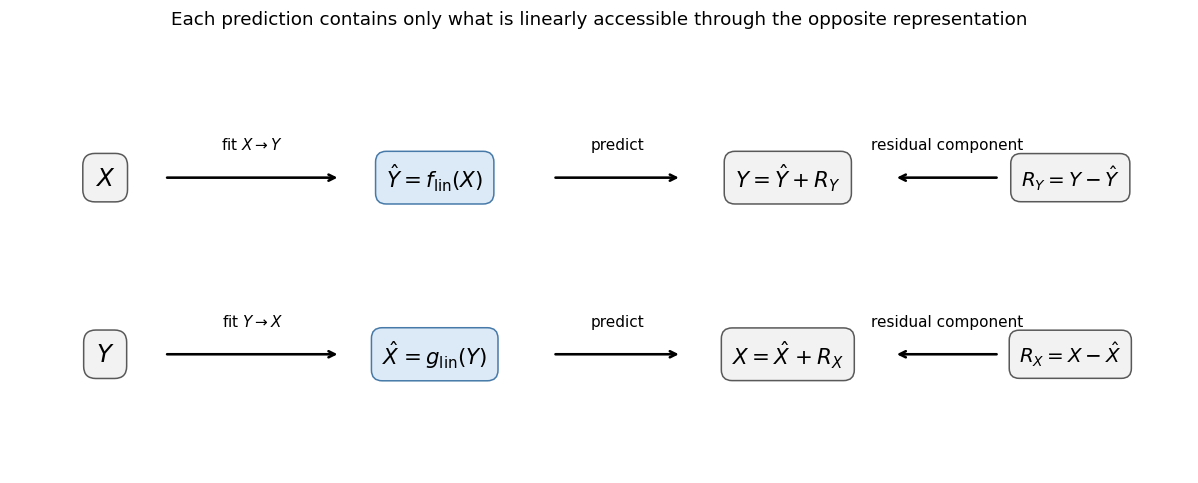

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.set(xlim=(0, 1), ylim=(0, 1))
ax.axis("off")

box = dict(boxstyle="round,pad=0.5", facecolor="0.95", edgecolor="0.35")
accent_box = dict(boxstyle="round,pad=0.5", facecolor="#dceaf7", edgecolor="#477aa8")

def diagram_arrow(start, end, label, label_y):
    ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="->", linewidth=1.7))
    ax.text((start[0] + end[0]) / 2, label_y, label, ha="center", va="bottom", fontsize=10)
# EOF


# X predicts Y on the upper lane.
ax.text(0.08, 0.70, r"$X$", ha="center", va="center", fontsize=16, bbox=box)
ax.text(0.36, 0.70, r"$\hat Y=f_{\rm lin}(X)$", ha="center", va="center", fontsize=14, bbox=accent_box)
ax.text(0.66, 0.70, r"$Y=\hat Y+R_Y$", ha="center", va="center", fontsize=14, bbox=box)
ax.text(0.90, 0.70, r"$R_Y=Y-\hat Y$", ha="center", va="center", fontsize=13, bbox=box)
diagram_arrow((0.13, 0.70), (0.28, 0.70), r"fit $X\rightarrow Y$", 0.76)
diagram_arrow((0.46, 0.70), (0.57, 0.70), "predict", 0.76)
diagram_arrow((0.84, 0.70), (0.75, 0.70), "residual component", 0.76)

# Y predicts X on the lower lane.
ax.text(0.08, 0.28, r"$Y$", ha="center", va="center", fontsize=16, bbox=box)
ax.text(0.36, 0.28, r"$\hat X=g_{\rm lin}(Y)$", ha="center", va="center", fontsize=14, bbox=accent_box)
ax.text(0.66, 0.28, r"$X=\hat X+R_X$", ha="center", va="center", fontsize=14, bbox=box)
ax.text(0.90, 0.28, r"$R_X=X-\hat X$", ha="center", va="center", fontsize=13, bbox=box)
diagram_arrow((0.13, 0.28), (0.28, 0.28), r"fit $Y\rightarrow X$", 0.34)
diagram_arrow((0.46, 0.28), (0.57, 0.28), "predict", 0.34)
diagram_arrow((0.84, 0.28), (0.75, 0.28), "residual component", 0.34)

ax.set_title("Each prediction contains only what is linearly accessible through the opposite representation", pad=18)
fig.tight_layout()

## 3. Scenario A — perfect invertible linear relations

**Mathematical fact.** If $Y=AX$ with invertible $A$, each representation is algebraically recoverable from the other. This does **not** imply that Euclidean nearest neighbors are identical: a generic linear map can shear or anisotropically scale space. A rotation followed by uniform scale is an isometry up to scale and therefore preserves Euclidean neighbor ordering, apart from numerical or exact-distance ties.

**Empirical question.** On held-out observations, how close are the regression residuals to zero, and how much neighborhood distortion remains for a mild generic map versus a rotation plus uniform scale?

Mild generic map determinant: 0.9850000000000001
Rotation-scale singular values: [1.7 1.7]


(<Figure size 1408x330 with 4 Axes>,
 array([[<Axes: title={'center': '$X$'}, xlabel='axis 1 (original coordinates)', ylabel='axis 2'>,
         <Axes: title={'center': '$Y$'}, xlabel='axis 1 (original coordinates)', ylabel='axis 2'>,
         <Axes: title={'center': '$\\hat X$'}, xlabel='axis 1 (original coordinates)', ylabel='axis 2'>,
         <Axes: title={'center': '$\\hat Y$'}, xlabel='axis 1 (original coordinates)', ylabel='axis 2'>]],
       dtype=object))

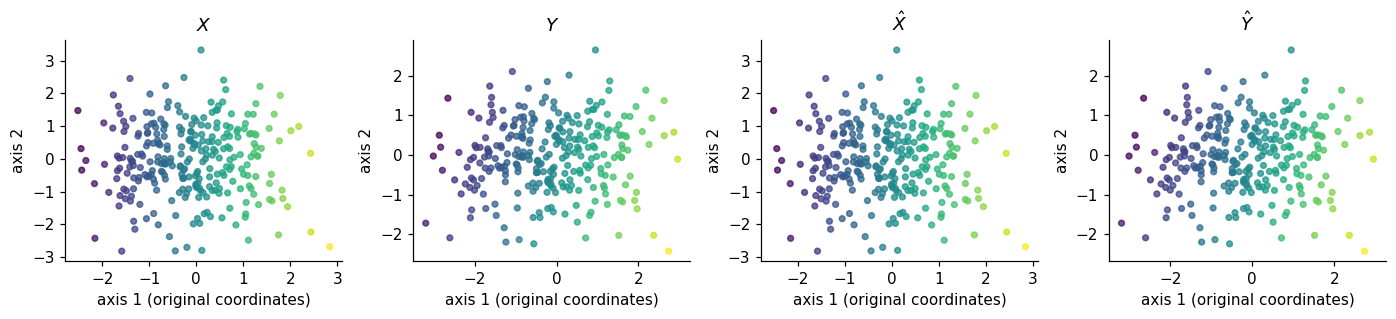

In [10]:
rng_A = np.random.default_rng(101)
X_A = rng_A.normal(size=(800, 2))

A_mild = np.array([[1.20, 0.25], [-0.10, 0.80]])
Y_A = X_A @ A_mild.T
result_A = fit_bidirectional_linear(
    X_A, Y_A, test_size=cfg.test_size, seed=102, alpha=cfg.regression_alpha
)

theta = np.deg2rad(38)
rotation = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
A_isometry = 1.7 * rotation
Y_A_iso = X_A @ A_isometry.T
result_A_iso = fit_bidirectional_linear(
    X_A, Y_A_iso, test_size=cfg.test_size, seed=102, alpha=cfg.regression_alpha
)

print("Mild generic map determinant:", np.linalg.det(A_mild))
print("Rotation-scale singular values:", np.linalg.svd(A_isometry, compute_uv=False))
plot_spaces(
    {r"$X$": result_A["X"], r"$Y$": result_A["Y"], r"$\hat X$": result_A["X_hat"], r"$\hat Y$": result_A["Y_hat"]},
    color=result_A["X"][:, 0],
)

| map | k | Delta(X -> Y) | Delta(Y -> X) | Delta(Xhat -> Yhat) | Delta(Yhat -> Xhat) | mean \|\|R_X\|\| | mean \|\|R_Y\|\| |
| --- | --- | --- | --- | --- | --- | --- | --- |
| mild generic A | 1 | 0.00158163 | 0.00158163 | 0.00158163 | 0.00158163 | 0.00006244 | 0.00002972 |
| mild generic A | 5 | 0.01737245 | 0.01718878 | 0.01737245 | 0.01718878 | 0.00006244 | 0.00002972 |
| rotation + uniform scale | 1 | 0.00000000 | 0.00000000 | 0.00000000 | 0.00000000 | 0.00004711 | 0.00003771 |
| rotation + uniform scale | 5 | 0.01428571 | 0.01428571 | 0.01428571 | 0.01428571 | 0.00004711 | 0.00003771 |

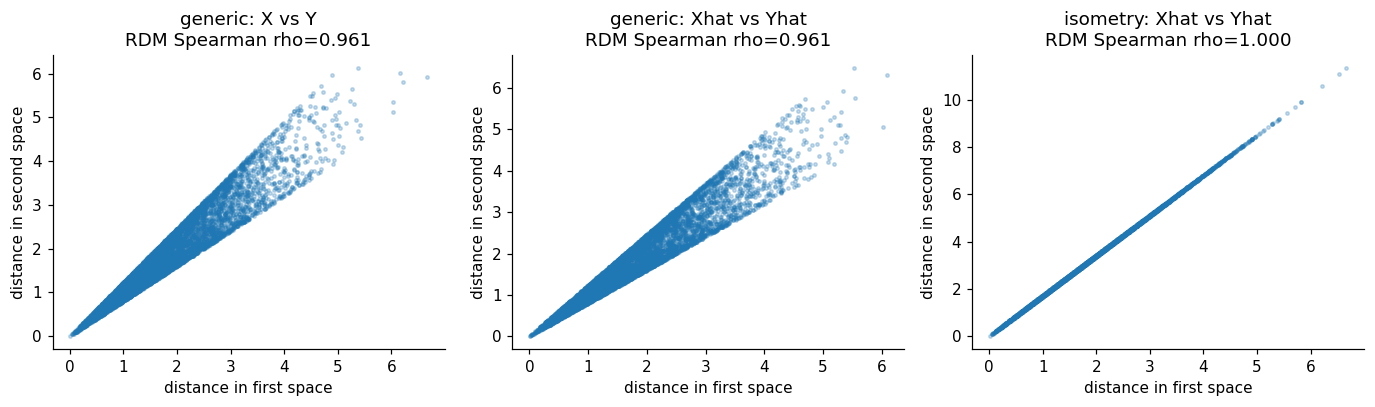

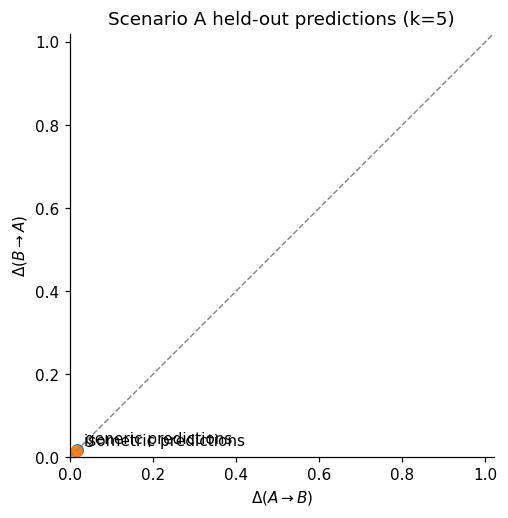

In [11]:
rows_A = []
for name, result in (("mild generic A", result_A), ("rotation + uniform scale", result_A_iso)):
    for k in (1, cfg.k):
        original = bidirectional_ii(result["X"], result["Y"], k)
        predicted = bidirectional_ii(result["X_hat"], result["Y_hat"], k)
        rows_A.append(
            {
                "map": name,
                "k": k,
                "Delta(X -> Y)": original[0],
                "Delta(Y -> X)": original[1],
                "Delta(Xhat -> Yhat)": predicted[0],
                "Delta(Yhat -> Xhat)": predicted[1],
                "mean ||R_X||": np.mean(np.linalg.norm(result["R_X"], axis=1)),
                "mean ||R_Y||": np.mean(np.linalg.norm(result["R_Y"], axis=1)),
            }
        )
    # end for k
# end for name, result
display_table(rows_A, precision=8)

plot_rdm_comparisons(
    {
        "generic: X vs Y": (result_A["X"], result_A["Y"]),
        "generic: Xhat vs Yhat": (result_A["X_hat"], result_A["Y_hat"]),
        "isometry: Xhat vs Yhat": (result_A_iso["X_hat"], result_A_iso["Y_hat"]),
    }
)

plot_ii_plane(
    {
        "generic predictions": bidirectional_ii(result_A["X_hat"], result_A["Y_hat"], cfg.k),
        "isometric predictions": bidirectional_ii(result_A_iso["X_hat"], result_A_iso["Y_hat"], cfg.k),
    },
    title=f"Scenario A held-out predictions (k={cfg.k})",
)
plt.show()

The isometric case reaches the project-convention minimum: zero at `k=1` and approximately `(k-1)/N_test` for larger `k`. The generic invertible map has zero regression error but slightly larger II because recoverability and Euclidean-neighborhood preservation are distinct properties.

| target | mean residual norm | mean held-out R² | mean \|corr(pred, residual)\| | RDM Spearman(pred, residual) | Delta(pred -> residual) | Delta(residual -> pred) |
| --- | --- | --- | --- | --- | --- | --- |
| X target | 0.0001 | 1.0000 | 0.6734 | 0.7867 | 0.0382 | 0.0398 |
| Y target | 0.0000 | 1.0000 | 0.6721 | 0.9123 | 0.0207 | 0.0214 |

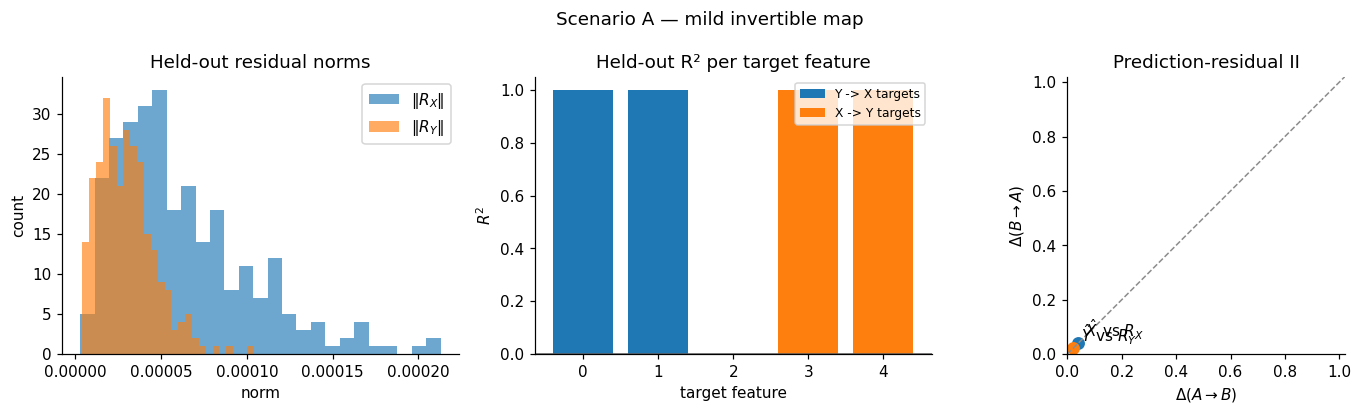

In [12]:
plot_residual_diagnostics(result_A, "Scenario A — mild invertible map", cfg.k)
plt.show()

## 4. Scenario B — nonlinear information concentrated in a residual

We generate

$$
X=x,\qquad Y=(x+\epsilon_1,\;10x^2+\epsilon_2),
$$

with symmetric $x$. **Mathematical fact:** in the population, $x$ and $x^2$ are uncorrelated under a symmetric distribution, so ordinary linear regression cannot reconstruct the quadratic coordinate from $x$. The quadratic structure should therefore concentrate in $R_Y$.

**Empirical caution:** the map $x\mapsto(x,x^2)$ is still a smooth one-dimensional curve, so its *local* nearest-neighbor geometry can remain similar to that of $x$, especially for small `k`. We report the simulation rather than forcing a large II difference.

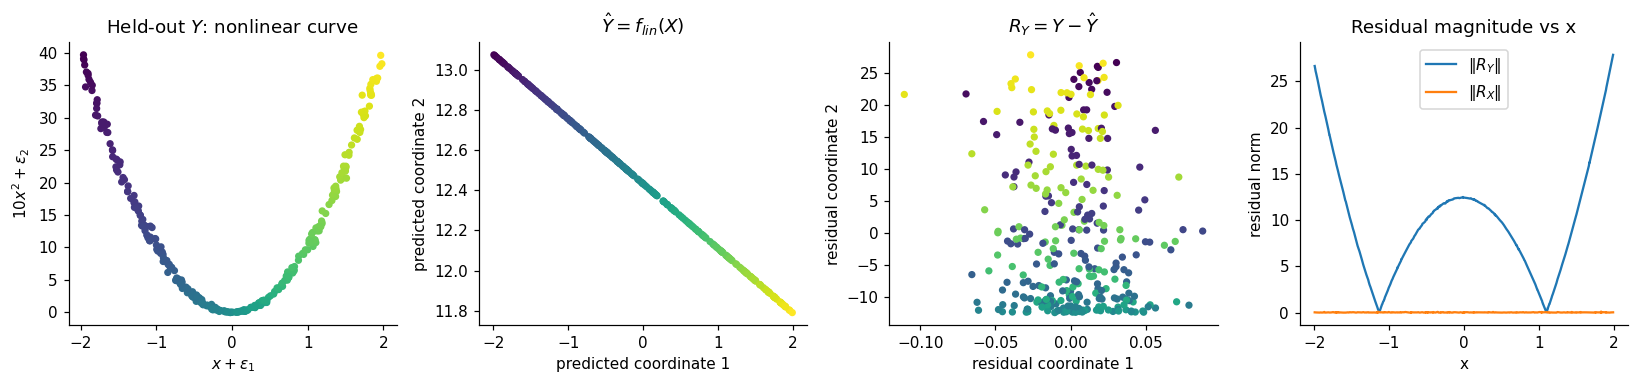

In [13]:
rng_B = np.random.default_rng(201)
x_B = rng_B.uniform(-2.0, 2.0, size=900)
noise_B = 0.03
X_B = x_B[:, None]
Y_B = np.column_stack(
    [
        x_B + noise_B * rng_B.normal(size=len(x_B)),
        10.0 * x_B**2 + noise_B * rng_B.normal(size=len(x_B)),
    ]
)
result_B = fit_bidirectional_linear(
    X_B, Y_B, test_size=cfg.test_size, seed=202, alpha=cfg.regression_alpha
)

x_test_B = result_B["X"][:, 0]
sort_B = np.argsort(x_test_B)
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
axes[0].scatter(result_B["Y"][:, 0], result_B["Y"][:, 1], c=x_test_B, cmap="viridis", s=14)
axes[0].set(title=r"Held-out $Y$: nonlinear curve", xlabel=r"$x+\epsilon_1$", ylabel=r"$10x^2+\epsilon_2$")
axes[1].scatter(result_B["Y_hat"][:, 0], result_B["Y_hat"][:, 1], c=x_test_B, cmap="viridis", s=14)
axes[1].set(title=r"$\hat Y=f_{lin}(X)$", xlabel="predicted coordinate 1", ylabel="predicted coordinate 2")
axes[2].scatter(result_B["R_Y"][:, 0], result_B["R_Y"][:, 1], c=x_test_B, cmap="viridis", s=14)
axes[2].set(title=r"$R_Y=Y-\hat Y$", xlabel="residual coordinate 1", ylabel="residual coordinate 2")
axes[3].plot(x_test_B[sort_B], np.linalg.norm(result_B["R_Y"], axis=1)[sort_B], label=r"$\|R_Y\|$")
axes[3].plot(x_test_B[sort_B], np.linalg.norm(result_B["R_X"], axis=1)[sort_B], label=r"$\|R_X\|$")
axes[3].set(title="Residual magnitude vs x", xlabel="x", ylabel="residual norm")
axes[3].legend()
fig.tight_layout()

| pair | k | Delta(A -> B) | Delta(B -> A) |
| --- | --- | --- | --- |
| X vs Y | 1 | 0.0028 | 0.0030 |
| X vs Yhat | 1 | 0.0000 | 0.0000 |
| Xhat vs Y | 1 | 0.0307 | 0.0251 |
| Xhat vs Yhat | 1 | 0.0304 | 0.0312 |
| R_Y vs Y | 1 | 0.0699 | 0.0078 |
| R_Y vs X | 1 | 0.7325 | 0.0117 |
| X vs Y | 5 | 0.0141 | 0.0141 |
| X vs Yhat | 5 | 0.0127 | 0.0127 |
| Xhat vs Y | 5 | 0.0364 | 0.0340 |
| Xhat vs Yhat | 5 | 0.0347 | 0.0347 |
| R_Y vs Y | 5 | 0.0700 | 0.0324 |
| R_Y vs X | 5 | 0.6899 | 0.0343 |
| X vs Y | 20 | 0.0795 | 0.3059 |
| X vs Yhat | 20 | 0.0603 | 0.0603 |
| Xhat vs Y | 20 | 0.0954 | 0.3118 |
| Xhat vs Yhat | 20 | 0.0681 | 0.0679 |
| R_Y vs Y | 20 | 0.0890 | 0.0935 |
| R_Y vs X | 20 | 0.6819 | 0.1276 |

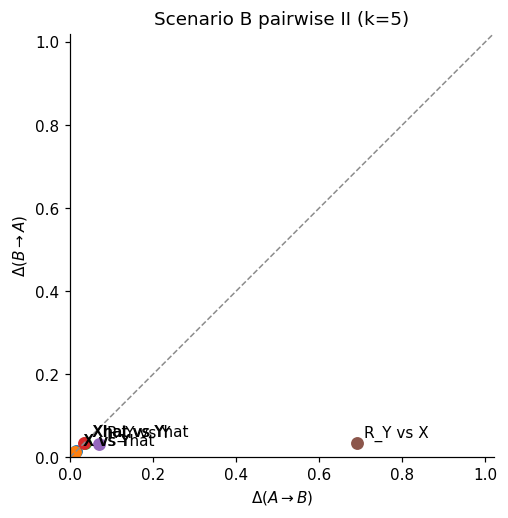

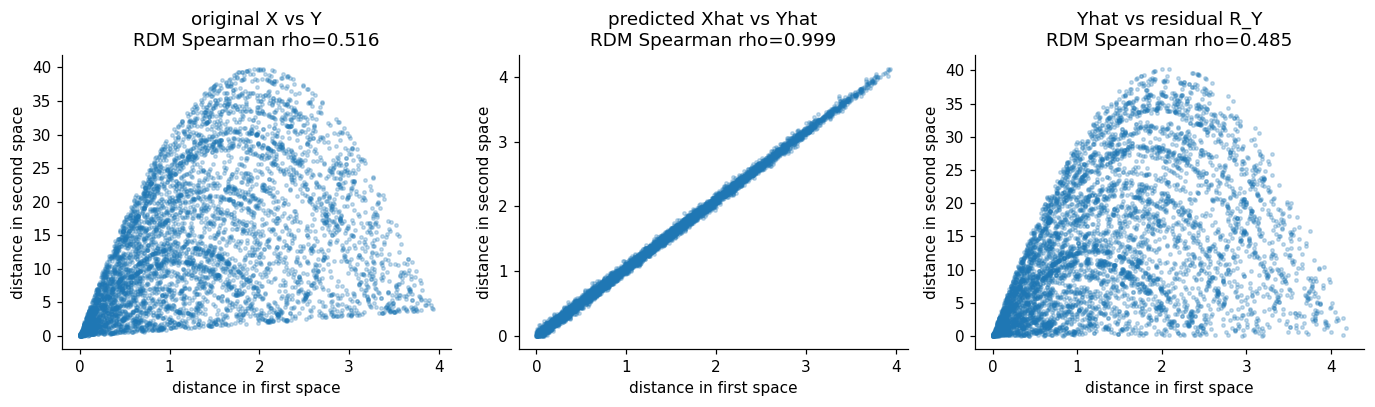

In [14]:
pairs_B = {
    "X vs Y": (result_B["X"], result_B["Y"]),
    "X vs Yhat": (result_B["X"], result_B["Y_hat"]),
    "Xhat vs Y": (result_B["X_hat"], result_B["Y"]),
    "Xhat vs Yhat": (result_B["X_hat"], result_B["Y_hat"]),
    "R_Y vs Y": (result_B["R_Y"], result_B["Y"]),
    "R_Y vs X": (result_B["R_Y"], result_B["X"]),
}

rows_B = []
for k in (1, cfg.k, 20):
    for label, (A, B) in pairs_B.items():
        a_to_b, b_to_a = bidirectional_ii(A, B, k)
        rows_B.append({"pair": label, "k": k, "Delta(A -> B)": a_to_b, "Delta(B -> A)": b_to_a})
    # end for label
# end for k
display_table(rows_B, precision=4)

plot_ii_plane(
    {label: bidirectional_ii(A, B, cfg.k) for label, (A, B) in pairs_B.items()},
    title=f"Scenario B pairwise II (k={cfg.k})",
)
plt.show()

plot_rdm_comparisons(
    {
        "original X vs Y": (result_B["X"], result_B["Y"]),
        "predicted Xhat vs Yhat": (result_B["X_hat"], result_B["Y_hat"]),
        "Yhat vs residual R_Y": (result_B["Y_hat"], result_B["R_Y"]),
    }
)
plt.show()

| target | mean residual norm | mean held-out R² | mean \|corr(pred, residual)\| | RDM Spearman(pred, residual) | Delta(pred -> residual) | Delta(residual -> pred) |
| --- | --- | --- | --- | --- | --- | --- |
| X target | 0.0230 | 0.9993 | 0.0959 | -0.0127 | 0.9568 | 1.0037 |
| Y target | 10.0166 | 0.4967 | 0.0900 | 0.4846 | 0.0343 | 0.6899 |

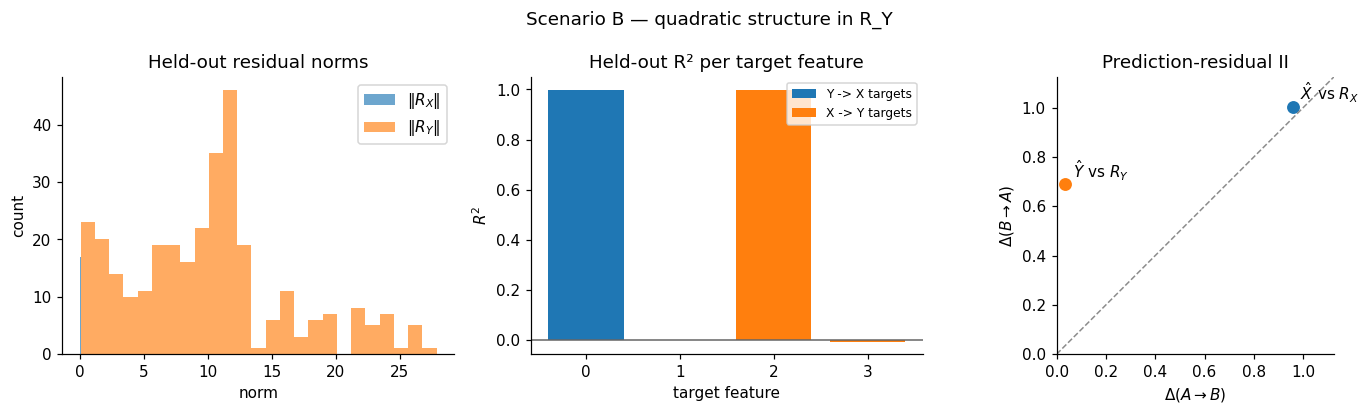

In [15]:
plot_residual_diagnostics(result_B, "Scenario B — quadratic structure in R_Y", cfg.k)
plt.show()

## 5. Scenario C — asymmetric information survives both linear projections

Let latent $(u,v)$ be cleanly represented by $X$, while the second coordinate of $Y$ is measured with much larger noise:

$$
X=(u,v),\qquad Y=(u+0.05\epsilon_1,\;v+4\epsilon_2).
$$

The forward fit can predict the noise-free part of both `Y` coordinates from `X`, so $\hat Y$ retains two directions. In the reverse fit, measurement error attenuates recovery of $v$, making $\hat X$ strongly anisotropic and nearly collapsed along that direction.

**Mathematical fact:** both fits are linear. Any II asymmetry arises from different effective rank or anisotropy of the predicted spaces—not from nonlinear regressors.

| direction | matrix rank | singular values |
| --- | --- | --- |
| X -> Y | 2 | [1.2306 0.9235] |
| Y -> X | 2 | [0.9707 0.2877] |

| space | effective dimension |
| --- | --- |
| X | 1.9871 |
| Y | 1.1196 |
| Xhat | 1.1566 |
| Yhat | 1.8425 |

Held-out R² X -> Y per target: [0.9974 0.0152]
Held-out R² Y -> X per target: [0.9974 0.0508]
Predicted-space II: [0.6084 0.2594]


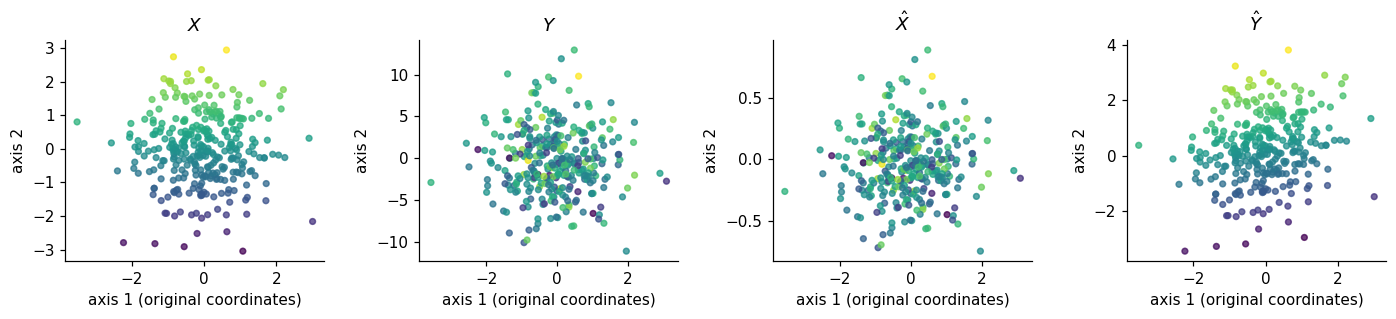

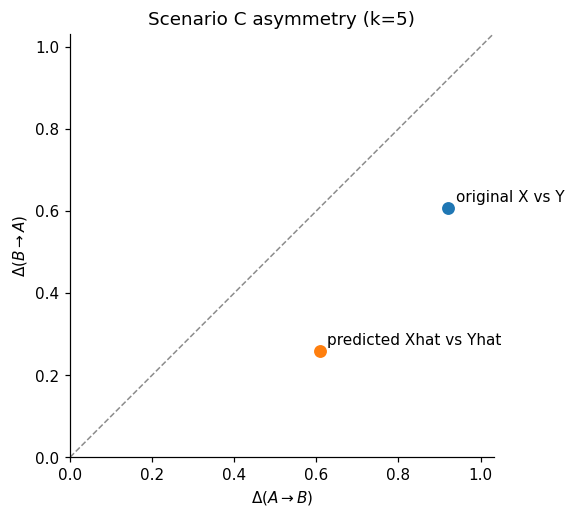

In [16]:
rng_C = np.random.default_rng(301)
latent_C = rng_C.normal(size=(900, 2))
X_C = latent_C.copy()
Y_C = np.column_stack(
    [
        latent_C[:, 0] + 0.05 * rng_C.normal(size=len(latent_C)),
        latent_C[:, 1] + 4.0 * rng_C.normal(size=len(latent_C)),
    ]
)
result_C = fit_bidirectional_linear(
    X_C, Y_C, test_size=cfg.test_size, seed=302, alpha=cfg.regression_alpha
)

coefficient_rows = []
for direction, model in (("X -> Y", result_C["X_to_Y"]), ("Y -> X", result_C["Y_to_X"])):
    singular_values = np.linalg.svd(model.get_weights(), compute_uv=False)
    coefficient_rows.append(
        {
            "direction": direction,
            "matrix rank": np.linalg.matrix_rank(model.get_weights()),
            "singular values": np.array2string(singular_values, precision=4),
        }
    )
# end for direction, model

dimension_table_C = [
    {"space": label, "effective dimension": effective_dimension(result_C[key])}
    for label, key in zip(("X", "Y", "Xhat", "Yhat"), ("X", "Y", "X_hat", "Y_hat"))
]
display_table(coefficient_rows, precision=4)
display_table(dimension_table_C, precision=4)
print("Held-out R² X -> Y per target:", np.round(result_C["r2_X_to_Y"], 4))
print("Held-out R² Y -> X per target:", np.round(result_C["r2_Y_to_X"], 4))
print("Predicted-space II:", np.round(bidirectional_ii(result_C["X_hat"], result_C["Y_hat"], cfg.k), 4))

plot_spaces(
    {r"$X$": result_C["X"], r"$Y$": result_C["Y"], r"$\hat X$": result_C["X_hat"], r"$\hat Y$": result_C["Y_hat"]},
    color=result_C["X"][:, 1],
)
plot_ii_plane(
    {
        "original X vs Y": bidirectional_ii(result_C["X"], result_C["Y"], cfg.k),
        "predicted Xhat vs Yhat": bidirectional_ii(result_C["X_hat"], result_C["Y_hat"], cfg.k),
    },
    title=f"Scenario C asymmetry (k={cfg.k})",
)
plt.show()

### Neighborhood-level view

The anchors below are selected because the rank of one space's nearest neighbor changes strongly in the other space. Point labels are original observation IDs, so identities remain consistent across panels. Ranks printed in the table are one-based for readability, although II uses zero-based ranks internally.

| anchor ID | nearest ID in $\hat X$ | its rank in $\hat Y$ | nearest ID in $\hat Y$ | its rank in $\hat X$ |
| --- | --- | --- | --- | --- |
| 238 | 478 | 311 | 120 | 4 |
| 182 | 522 | 310 | 11 | 15 |
| 637 | 118 | 304 | 65 | 14 |

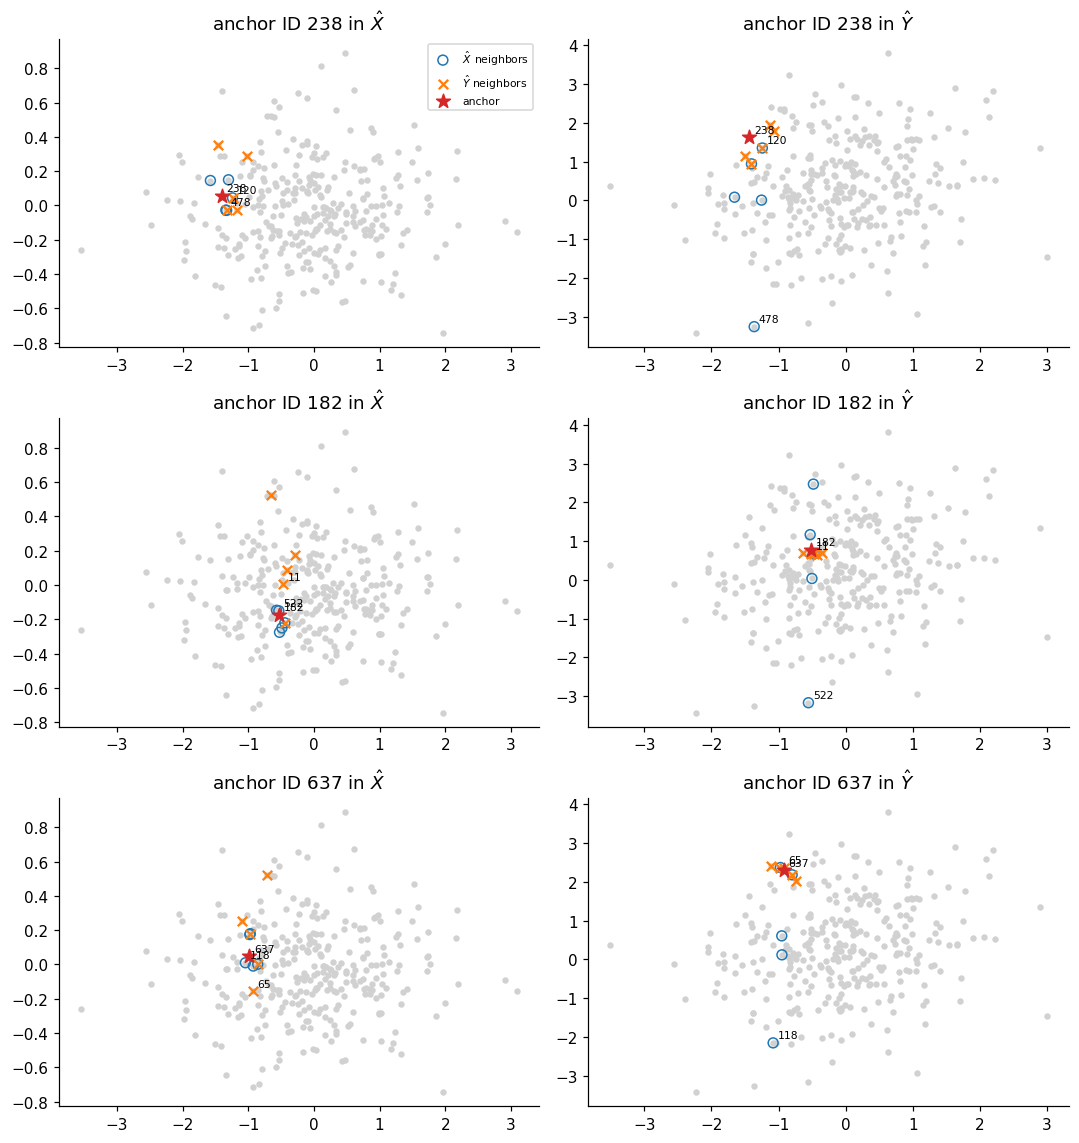

In [17]:
rank_records_C = neighborhood_rank_records(result_C["X_hat"], result_C["Y_hat"])
for row in rank_records_C:
    row["directional mismatch"] = (
        row["rank of A nearest in B"] - row["rank of B nearest in A"]
    )
# end for row
anchors_C = np.array(
    [row["anchor"] for row in sorted(rank_records_C, key=lambda row: row["directional mismatch"], reverse=True)[:3]]
)

_, _, neighborhood_statements_C = plot_local_neighborhoods(
    result_C["X_hat"],
    result_C["Y_hat"],
    anchors=anchors_C,
    point_ids=result_C["test_idx"],
    k=cfg.k,
    labels=(r"$\hat X$", r"$\hat Y$"),
)
display_table(neighborhood_statements_C, precision=0)
plt.show()

| target | mean residual norm | mean held-out R² | mean \|corr(pred, residual)\| | RDM Spearman(pred, residual) | Delta(pred -> residual) | Delta(residual -> pred) |
| --- | --- | --- | --- | --- | --- | --- |
| X target | 0.7984 | 0.5241 | 0.0305 | -0.0225 | 0.9893 | 1.0329 |
| Y target | 3.1334 | 0.5063 | 0.0746 | -0.0080 | 1.0134 | 0.9827 |

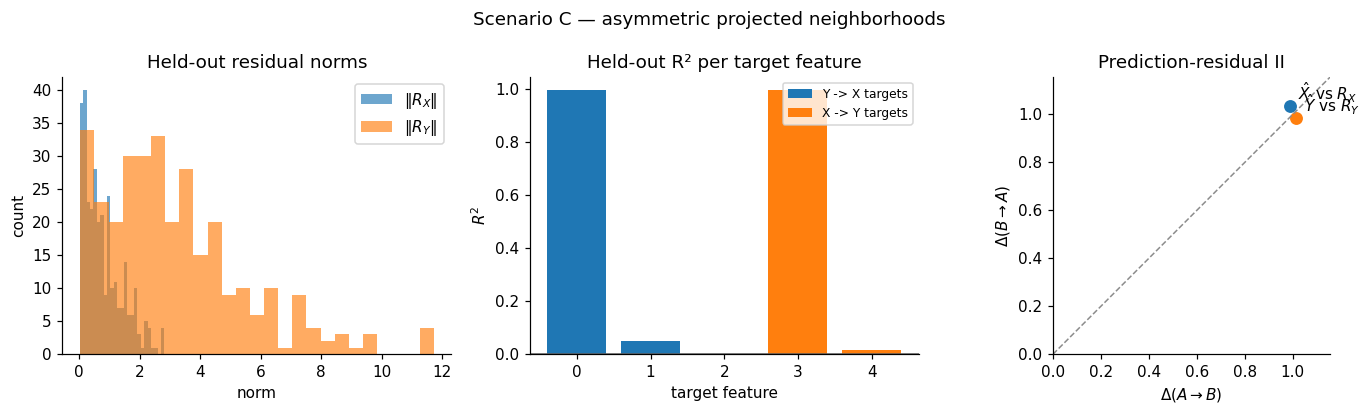

In [18]:
plot_residual_diagnostics(result_C, "Scenario C — asymmetric projected neighborhoods", cfg.k)
plt.show()

## 6. Scenario D — shared linear and unique nonlinear components

We now use

$$
X=(u,v),\qquad
Y=(u,\;v,\;10u^2,\;5\sin v)+\epsilon.
$$

The first two `Y` coordinates share linearly predictable geometry with `X`. The quadratic coordinate is nearly orthogonal to `u` under symmetric sampling, while `sin(v)` remains partly linearly correlated with `v`; some nonlinear structure can therefore survive indirectly in $\hat Y$. The remaining nonlinear geometry is concentrated in $R_Y$.

PCA is used below only to display spaces with more than two features. Every RDM and II value is computed in the original feature space.

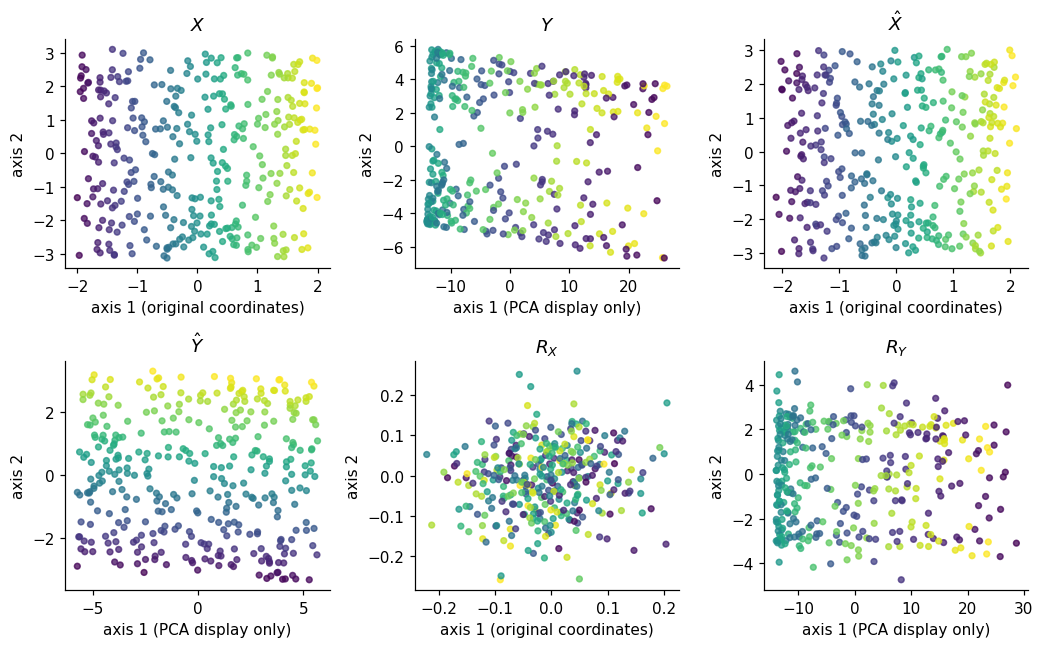

In [19]:
def generate_scenario_D(n_observations=1000, noise=0.08, nonlinear_strength=1.0, seed=401):
    """Generate shared linear coordinates plus quadratic and sinusoidal coordinates."""
    rng = np.random.default_rng(seed)
    u = rng.uniform(-2.0, 2.0, size=n_observations)
    v = rng.uniform(-np.pi, np.pi, size=n_observations)
    X = np.column_stack([u, v])
    Y = np.column_stack(
        [
            u,
            v,
            10.0 * nonlinear_strength * u**2,
            5.0 * nonlinear_strength * np.sin(v),
        ]
    )
    Y = Y + noise * rng.normal(size=Y.shape)
    return X, Y
# EOF


X_D, Y_D = generate_scenario_D()
result_D = fit_bidirectional_linear(
    X_D, Y_D, test_size=cfg.test_size, seed=402, alpha=0.01
)

plot_spaces(
    {
        r"$X$": result_D["X"],
        r"$Y$": result_D["Y"],
        r"$\hat X$": result_D["X_hat"],
        r"$\hat Y$": result_D["Y_hat"],
        r"$R_X$": result_D["R_X"],
        r"$R_Y$": result_D["R_Y"],
    },
    color=result_D["X"][:, 0],
    ncols=3,
)
plt.show()

| pair | Delta(A -> B) | Delta(B -> A) | RDM Spearman |
| --- | --- | --- | --- |
| X vs Y | 0.1158 | 0.1658 | 0.2635 |
| Xhat vs Yhat | 0.0190 | 0.0190 | 0.9923 |
| R_X vs R_Y | 0.9837 | 0.9706 | 0.0324 |
| Xhat vs R_Y | 0.2292 | 0.8597 | 0.1383 |
| Yhat vs R_Y | 0.2127 | 0.8513 | 0.1172 |

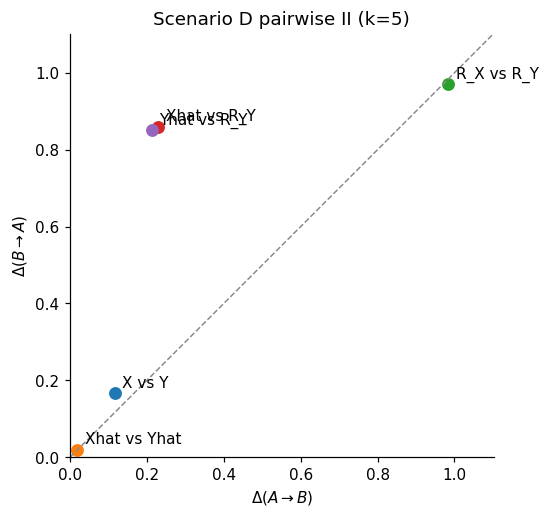

In [20]:
pairs_D = {
    "X vs Y": (result_D["X"], result_D["Y"]),
    "Xhat vs Yhat": (result_D["X_hat"], result_D["Y_hat"]),
    "R_X vs R_Y": (result_D["R_X"], result_D["R_Y"]),
    "Xhat vs R_Y": (result_D["X_hat"], result_D["R_Y"]),
    "Yhat vs R_Y": (result_D["Y_hat"], result_D["R_Y"]),
}

ii_rows_D = []
for label, (A, B) in pairs_D.items():
    delta_A_B, delta_B_A = safe_bidirectional_ii(A, B, cfg.k)
    ii_rows_D.append(
        {
            "pair": label,
            "Delta(A -> B)": delta_A_B,
            "Delta(B -> A)": delta_B_A,
            "RDM Spearman": rdm_spearman(A, B),
        }
    )
# end for label
display_table(ii_rows_D, precision=4)

finite_pairs_D = {
    label: safe_bidirectional_ii(A, B, cfg.k)
    for label, (A, B) in pairs_D.items()
    if np.isfinite(safe_bidirectional_ii(A, B, cfg.k)).all()
}
plot_ii_plane(finite_pairs_D, title=f"Scenario D pairwise II (k={cfg.k})")
plt.show()

| target | mean residual norm | mean held-out R² | mean \|corr(pred, residual)\| | RDM Spearman(pred, residual) | Delta(pred -> residual) | Delta(residual -> pred) |
| --- | --- | --- | --- | --- | --- | --- |
| X target | 0.1047 | 0.9966 | 0.0815 | 0.0240 | 0.9848 | 0.9486 |
| Y target | 10.9690 | 0.6485 | 0.0795 | 0.1172 | 0.2127 | 0.8513 |

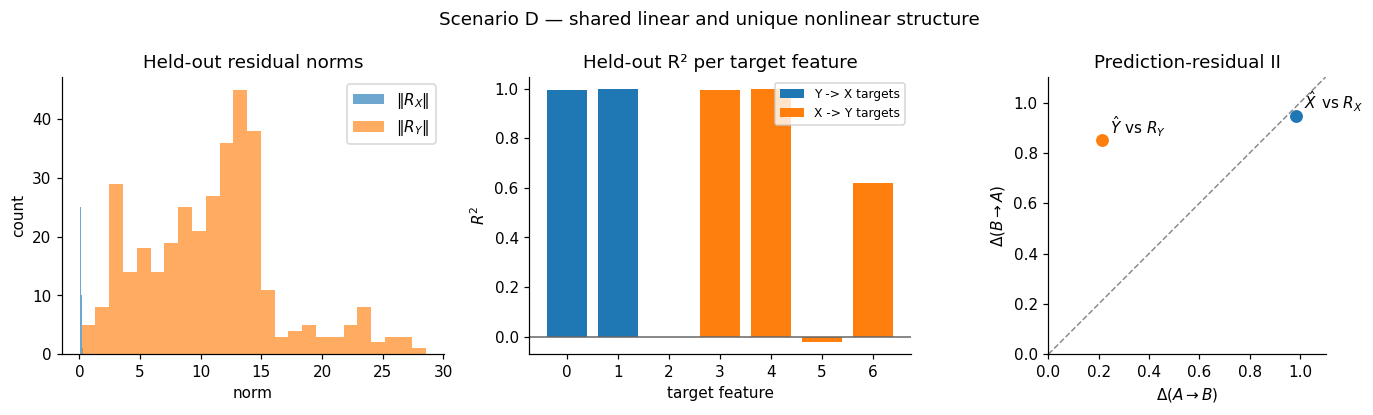

In [21]:
plot_residual_diagnostics(result_D, "Scenario D — shared linear and unique nonlinear structure", cfg.k)
plt.show()

## 7. Summary comparison

The table uses one common held-out neighborhood size. These are empirical results for the displayed seeds and sample sizes, not universal constants.

In [22]:
summary_rows = [
    scenario_summary(
        "A — mild invertible",
        "Y = A X, mild anisotropy",
        result_A,
        cfg.k,
        "Exact recoverability; small neighborhood distortion remains.",
    ),
    scenario_summary(
        "A2 — rotation-scale",
        "Y = s Q X",
        result_A_iso,
        cfg.k,
        "Isometric up to scale; II reaches the finite-k minimum.",
    ),
    scenario_summary(
        "B — quadratic residual",
        "Y = (x, 10 x²) + noise",
        result_B,
        cfg.k,
        "Quadratic structure is mostly in R_Y; local curve geometry can still agree.",
    ),
    scenario_summary(
        "C — noisy second coordinate",
        "Y = (u + small noise, v + large noise)",
        result_C,
        cfg.k,
        "Reverse prediction collapses v; projected neighborhoods are asymmetric.",
    ),
    scenario_summary(
        "D — shared + nonlinear",
        "Y = (u, v, 10u², 5sin(v)) + noise",
        result_D,
        cfg.k,
        "Shared linear geometry survives; unique nonlinear geometry moves to R_Y.",
    ),
]
display_table(summary_rows, precision=4)

| scenario | relation generating Y | R² X -> Y | R² Y -> X | Delta(X -> Y) | Delta(Y -> X) | Delta(Xhat -> Yhat) | Delta(Yhat -> Xhat) | mean \|\|R_X\|\| | mean \|\|R_Y\|\| | interpretation |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| A — mild invertible | Y = A X, mild anisotropy | 1.0000 | 1.0000 | 0.0174 | 0.0172 | 0.0174 | 0.0172 | 0.0001 | 0.0000 | Exact recoverability; small neighborhood distortion remains. |
| A2 — rotation-scale | Y = s Q X | 1.0000 | 1.0000 | 0.0143 | 0.0143 | 0.0143 | 0.0143 | 0.0000 | 0.0000 | Isometric up to scale; II reaches the finite-k minimum. |
| B — quadratic residual | Y = (x, 10 x²) + noise | 0.4967 | 0.9993 | 0.0141 | 0.0141 | 0.0347 | 0.0347 | 0.0230 | 10.0166 | Quadratic structure is mostly in R_Y; local curve geometry can still agree. |
| C — noisy second coordinate | Y = (u + small noise, v + large noise) | 0.5063 | 0.5241 | 0.9211 | 0.6079 | 0.6084 | 0.2594 | 0.7984 | 3.1334 | Reverse prediction collapses v; projected neighborhoods are asymmetric. |
| D — shared + nonlinear | Y = (u, v, 10u², 5sin(v)) + noise | 0.6485 | 0.9966 | 0.1158 | 0.1658 | 0.0190 | 0.0190 | 0.1047 | 10.9690 | Shared linear geometry survives; unique nonlinear geometry moves to R_Y. |

## 8. Additional robustness analyses

The following modest sweeps vary one quantity at a time. Each point refits both regressions and evaluates predicted-space II on held-out observations. The sweep seed is explicit and fixed within each panel so changes primarily reflect the varied parameter. The `k` sweep reuses one held-out fit.

In [23]:
def generate_scenario_C(n_observations=900, noisy_coordinate_sd=4.0, seed=501):
    """Generate the anisotropic measurement-error example used in Scenario C."""
    rng = np.random.default_rng(seed)
    latent = rng.normal(size=(n_observations, 2))
    X = latent.copy()
    Y = np.column_stack(
        [
            latent[:, 0] + 0.05 * rng.normal(size=n_observations),
            latent[:, 1] + noisy_coordinate_sd * rng.normal(size=n_observations),
        ]
    )
    return X, Y
# EOF


def predicted_ii_from_data(X, Y, seed, alpha, k):
    """Fit held-out bidirectional regressions and return predicted-space II."""
    result = fit_bidirectional_linear(
        X, Y, test_size=cfg.test_size, seed=seed, alpha=alpha
    )
    return bidirectional_ii(result["X_hat"], result["Y_hat"], k)
# EOF


sweep_results = {}

# Sample size sweep on Scenario D.
sample_sizes = [250, 400, 700, 1100]
sweep_results["sample size"] = [
    predicted_ii_from_data(
        *generate_scenario_D(n_observations=n, seed=601), seed=602, alpha=0.01, k=cfg.k
    )
    for n in sample_sizes
]

# Observation-noise sweep on Scenario D.
noise_levels = [0.0, 0.05, 0.2, 0.6]
sweep_results["observation noise"] = [
    predicted_ii_from_data(
        *generate_scenario_D(noise=noise, seed=611), seed=612, alpha=0.01, k=cfg.k
    )
    for noise in noise_levels
]

# Nonlinear strength sweep on Scenario D.
nonlinear_strengths = [0.0, 0.25, 0.5, 1.0, 1.5]
sweep_results["nonlinear strength"] = [
    predicted_ii_from_data(
        *generate_scenario_D(nonlinear_strength=strength, seed=621),
        seed=622,
        alpha=0.01,
        k=cfg.k,
    )
    for strength in nonlinear_strengths
]

# Ridge-regularization sweep on Scenario C.
regularization_values = [0.0, 1e-4, 1e-2, 1e-1, 1.0, 10.0]
X_sweep_C, Y_sweep_C = generate_scenario_C(seed=631)
sweep_results["ridge alpha"] = [
    predicted_ii_from_data(X_sweep_C, Y_sweep_C, seed=632, alpha=alpha, k=cfg.k)
    for alpha in regularization_values
]

# Neighborhood-size sweep reuses the Scenario C held-out predictions.
k_values = [1, 3, 5, 10, 20, 40]
sweep_results["k"] = [
    bidirectional_ii(result_C["X_hat"], result_C["Y_hat"], k) for k in k_values
]

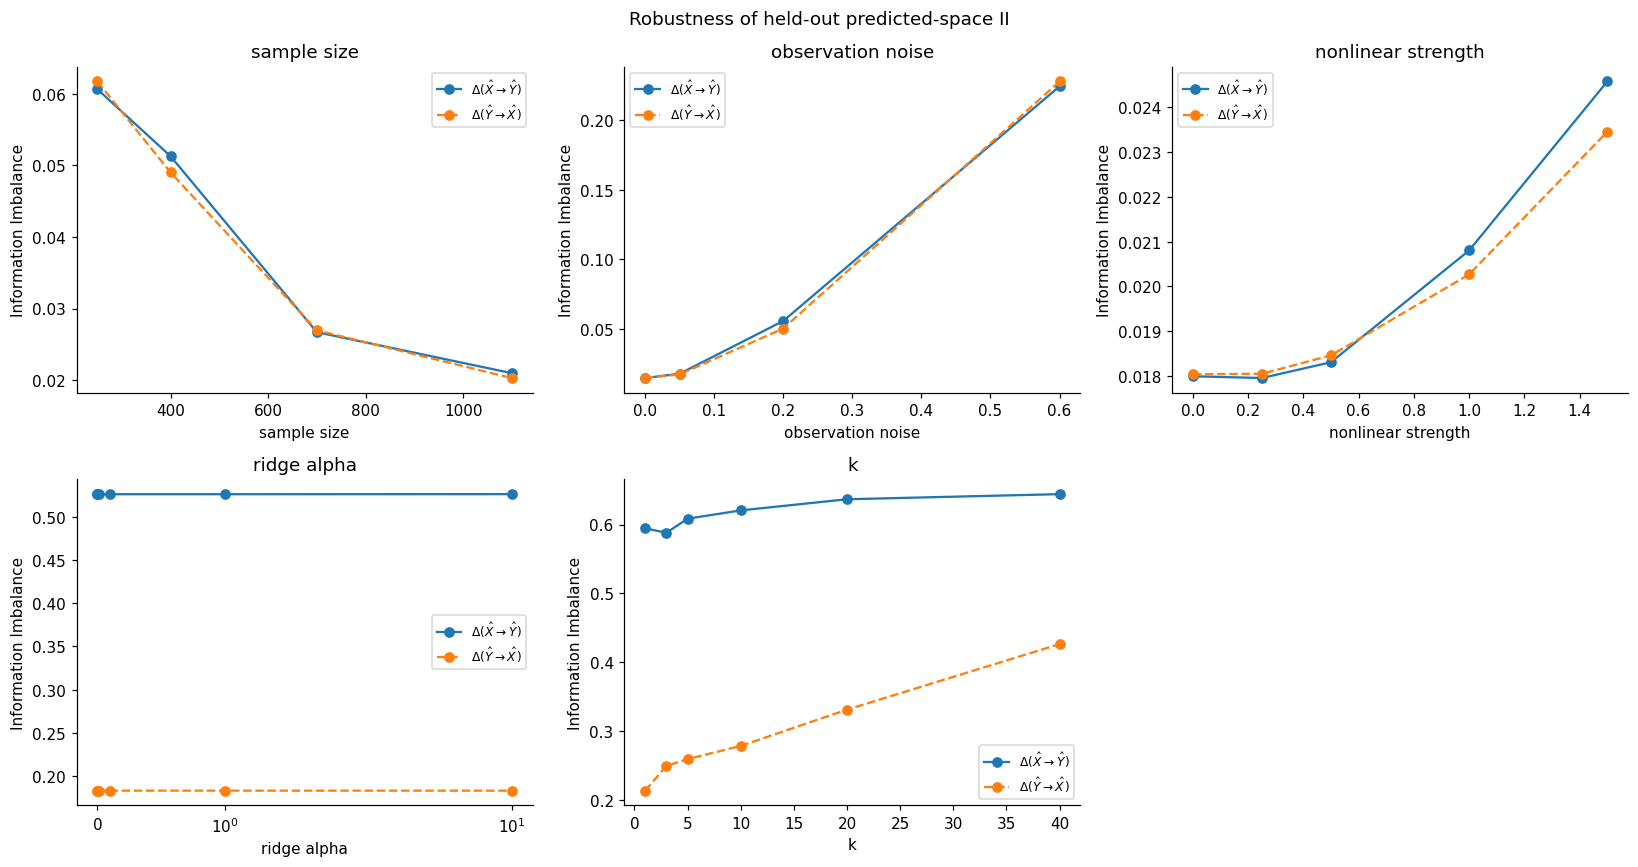

In [24]:
sweep_axes = [
    ("sample size", sample_sizes, "linear"),
    ("observation noise", noise_levels, "linear"),
    ("nonlinear strength", nonlinear_strengths, "linear"),
    ("ridge alpha", regularization_values, "symlog"),
    ("k", k_values, "linear"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, x_values, x_scale) in zip(axes.flat, sweep_axes):
    values = np.asarray(sweep_results[name])
    ax.plot(x_values, values[:, 0], marker="o", label=r"$\Delta(\hat X\rightarrow\hat Y)$")
    ax.plot(x_values, values[:, 1], marker="o", linestyle="--", label=r"$\Delta(\hat Y\rightarrow\hat X)$")
    ax.set(xlabel=name, ylabel="Information Imbalance", title=name)
    ax.set_xscale(x_scale)
    ax.legend(fontsize=8)
# end for ax
axes.flat[-1].axis("off")
fig.suptitle("Robustness of held-out predicted-space II")
fig.tight_layout()

## 9. Final conceptual conclusions

The simulations support the following interpretation, while the numerical values remain specific to their seeds and parameters:

1. $\hat X$ and $\hat Y$ contain only information linearly predictable through the opposite space.
2. Nonlinear structure can survive indirectly when it is correlated with linearly predictable coordinates, but purely nonlinear residual structure is excluded before $\mathrm{II}(\hat X,\hat Y)$ is computed.
3. II can remain asymmetric between two linear projections because II measures directional local-neighborhood containment, not whether the coordinates were produced by linear maps.
4. Low residual error does not guarantee II near zero. General invertible linear transformations can distort Euclidean neighborhoods even when information is algebraically recoverable.
5. II near zero does not prove a perfect linear relation between the original $X$ and $Y$. Different nonlinear or noisy constructions can preserve similar local neighbor identities.
6. A more informative analysis considers
   $$
   \mathrm{II}(X,Y),\qquad \mathrm{II}(\hat X,\hat Y),\qquad \mathrm{II}(R_X,R_Y),
   $$
   together with prediction–residual cross-pairs and held-out $R^2$.
7. Least-squares residuals are orthogonal to the fitted predictor design on the training data. They need not be statistically independent of predictions, nor have unrelated distance geometry, on held-out observations.
8. Conclusions should be checked across neighborhood sizes $k$, sample sizes, noise levels, regularization strengths, nonlinear-component strengths, and random seeds.